In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

In [2]:
RAW_DATA_PATH = '../data/raw/raw_text.csv'
dataset = pd.read_csv(RAW_DATA_PATH)

# Display the first few rows of the dataset
dataset.head()

,Text,Label
0,We’re all going to a walk around the city Satu...,No
1,"Hey, I don’t want to say it too directly but… ...",Yes
2,"Lowkey, is the assignment due after class or S...",No
3,Can you check if my presentation i...,No
4,Can you grab me batteries on the ...,No


In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 837 entries, 0 to 836
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Text    812 non-null    object
 1   Label   837 non-null    object
dtypes: object(2)
memory usage: 13.2+ KB


In [4]:
# Convert any labels value into only 1 and 0 
dataset['label'] = dataset['Label'].map({'Yes': 1, 'No': 0})
dataset['Text'] = dataset['Text'].astype(str) # Convert all text to string type

cleaned_dataset = dataset.dropna(subset=['Text', 'Label'])
# Fix: Do not use inplace=True to avoid NoneType error
cleaned_dataset = cleaned_dataset.drop_duplicates(subset=['Text'])

# Normalized whitespace
cleaned_dataset['Text'] = cleaned_dataset['Text'].replace(r"\s+", " ", regex=True).str.strip()

cleaned_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 813 entries, 0 to 836
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Text    813 non-null    object
 1   Label   813 non-null    object
 2   label   813 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 25.4+ KB


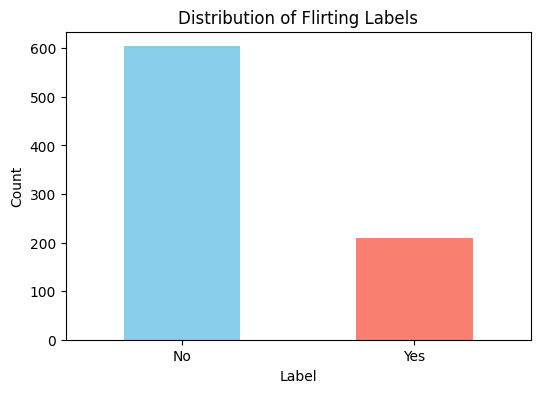

In [5]:
# distribution of labels
label_counts = cleaned_dataset['label'].value_counts()
plt.figure(figsize=(6, 4))
label_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution of Flirting Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'], rotation=0)
plt.show()


In [6]:
#Train test split dataset, %80 train, %10 val, %10 test, keeping the label distribution ratio the same
from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(cleaned_dataset, test_size=0.2, random_state=42, stratify=cleaned_dataset['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])
len(train_df), len(val_df), len(test_df)

(650, 81, 82)

In [7]:
train_df.head()

,Text,Label,label
735,"Honestly, are you free tomorrow for a quick ca...",No,0
394,What bus do you usually take? ✨,No,0
302,"Lowkey, did you pay the bill for submission?",No,0
271,Please don’t forget to bring the drinks 😏,No,0
125,"Btw, can you check if my shop is correct? 😅",No,0


In [8]:
from datasets import Dataset
#Conver†ing pandas dataframes to huggingface datasets
#Benefits: efficient, faster, and compatible with transformers library

train_ds = Dataset.from_pandas(train_df[['Text', 'label']].reset_index(drop=True))
val_ds = Dataset.from_pandas(val_df[['Text', 'label']].reset_index(drop=True))
test_ds = Dataset.from_pandas(test_df[['Text', 'label']].reset_index(drop=True))

In [10]:
from transformers import AutoTokenizer
checkpoint = "distilbert/distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
#Tokenize the datasets
def tokenize_preprocess_function(examples):
    return tokenizer(examples["Text"], truncation=True)
train_tokenized = train_ds.map(tokenize_preprocess_function, batched=True)
val_tokenized = val_ds.map(tokenize_preprocess_function, batched=True)
test_tokenized = test_ds.map(tokenize_preprocess_function, batched=True)

#Dynamic padding and batching using DataCollator, 
#Pads each batch to the maximum length instead of a fixed max length
from transformers import DataCollatorWithPadding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


Map:   0%|          | 0/650 [00:00<?, ? examples/s]

Map:   0%|          | 0/81 [00:00<?, ? examples/s]

Map:   0%|          | 0/82 [00:00<?, ? examples/s]

In [1]:
import evaluate
import numpy as np

accuracy_metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=predictions, references=labels)

id2label = {0: "No", 1: "Yes"}
label2id = {"No": 0, "Yes": 1} 

from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)
training_args = TrainingArguments(
    output_dir="./flirt_distilbert",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
trainer.train()

NameError: name 'checkpoint' is not defined